In [1]:
import numpy as np
import matplotlib.pyplot as plt

import lightkurve as lk
import emcee
import corner

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


C:\Users\Miguel Miranda\miniconda3\envs\kepler10b\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
search_result = lk.search_lightcurve(
    "Kepler-10",
    mission="Kepler",
    cadence="long"
)

search_result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
1,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
2,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
4,Kepler Quarter 04,2010,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 05,2010,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 06,2010,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 07,2010,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr011904151,0.0


In [3]:
lc_collection = search_result[:10].download_all()

lc_stitched = (
    lc_collection
    .stitch()
    .remove_nans()
    .remove_outliers(sigma=5)
    .normalize()
)

lc_stitched

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
120.5391465105713,9.9973351e-01,4.1018640e-05,0,9.940906e-04,659.36896,250.31948,568,5.3272462e+05,2.0045162e+01,2.4877234e+03,1.3237703e+00,5.0146684e+05,2.0574972e+01,0,———,———,———,———,659.36896,3.6308160e-05,250.31948,5.3553398e-05,1.7792054e-03,3.3286733e-03
120.55958073025249,9.9962443e-01,4.1064202e-05,0,9.947103e-04,659.36919,250.31978,569,5.3274544e+05,2.0045479e+01,2.4910432e+03,1.3229831e+00,5.0141212e+05,2.0597826e+01,0,———,———,———,———,659.36919,3.6305861e-05,250.31978,5.3553318e-05,1.9566093e-03,3.5631030e-03
120.58001484981651,9.9960583e-01,4.1136471e-05,0,9.953298e-04,659.36918,250.31934,570,5.3274400e+05,2.0045910e+01,2.4830063e+03,1.3249981e+00,5.0140281e+05,2.0634075e+01,0,———,———,———,———,659.36918,3.6309517e-05,250.31934,5.3547948e-05,2.0698714e-03,3.4072644e-03
120.60044916937477,9.9951994e-01,4.1083946e-05,0,9.959494e-04,659.36967,250.31932,571,5.3266388e+05,2.0044411e+01,2.4886853e+03,1.3235550e+00,5.0135972e+05,2.0607729e+01,0,———,———,———,———,659.36967,3.6312224e-05,250.31932,5.3564647e-05,2.4259784e-03,3.0491522e-03
120.62088338893955,9.9969512e-01,4.1039806e-05,0,9.965689e-04,659.36989,250.31906,572,5.3276494e+05,2.0046177e+01,2.4869612e+03,1.3239022e+00,5.0144759e+05,2.0585588e+01,0,———,———,———,———,659.36989,3.6307927e-05,250.31906,5.3543699e-05,2.7262936e-03,3.2327282e-03
120.64131750838715,9.9964851e-01,4.1113399e-05,0,9.971884e-04,659.37001,250.31846,573,5.3270619e+05,2.0045256e+01,2.4852412e+03,1.3248761e+00,5.0142422e+05,2.0622503e+01,0,———,———,———,———,659.37001,3.6310295e-05,250.31846,5.3552700e-05,2.8024365e-03,2.5497559e-03
120.66175172782823,9.9949282e-01,4.1062165e-05,0,9.978078e-04,659.37024,250.31868,574,5.3262088e+05,2.0043943e+01,2.4874382e+03,1.3227766e+00,5.0134612e+05,2.0596804e+01,0,———,———,———,———,659.37024,3.6316073e-05,250.31868,5.3557891e-05,2.9968296e-03,2.9109719e-03
120.68218604727736,9.9953902e-01,4.1014217e-05,0,9.984273e-04,659.37011,250.31860,575,5.3262475e+05,2.0044262e+01,2.4853333e+03,1.3250123e+00,5.0136928e+05,2.0572752e+01,0,———,———,———,———,659.37011,3.6316418e-05,250.31860,5.3558793e-05,2.9321318e-03,2.7981971e-03


In [4]:
t = lc_stitched.time.value
flux = lc_stitched.flux.value

try:
    flux_err = lc_stitched.flux_err.value
    mask_err = np.isfinite(flux_err) & (flux_err > 0)

    if np.sum(mask_err) < 0.5 * len(flux_err):
        raise ValueError("flux_err no parece útil")

except:
    flux_err = np.ones_like(flux) * np.std(flux - np.median(flux))

mask = (
    np.isfinite(t)
    & np.isfinite(flux)
    & np.isfinite(flux_err)
    & (flux_err > 0)
)

t = t[mask]
flux = flux[mask]
flux_err = flux_err[mask]

print("Número de datos:", len(t))
print("Tiempo mínimo:", t.min())
print("Tiempo máximo:", t.max())
print("Flujo medio:", np.mean(flux))
print("Desviación estándar del flujo:", np.std(flux))

Número de datos: 33182
Tiempo mínimo: 120.5391465105713
Tiempo máximo: 1000.2679756718862
Flujo medio: 0.9999927
Desviación estándar del flujo: 0.0002060623


In [5]:
def fold_time(t, P, T0):
    phase = ((t - T0 + 0.5 * P) % P) - 0.5 * P
    return phase

In [6]:
P_ref = 0.837
T0_guess = t[np.argmin(flux)]

phase = fold_time(t, P_ref, T0_guess)

In [7]:
def bin_data_weighted(x, y, yerr, nbins=300):
    bins = np.linspace(x.min(), x.max(), nbins + 1)

    x_bin = np.zeros(nbins)
    y_bin = np.zeros(nbins)
    yerr_bin = np.zeros(nbins)

    for i in range(nbins):
        mask_bin = (x >= bins[i]) & (x < bins[i + 1])

        if np.sum(mask_bin) > 0:
            x_i = x[mask_bin]
            y_i = y[mask_bin]
            yerr_i = yerr[mask_bin]

            good = (
                np.isfinite(x_i)
                & np.isfinite(y_i)
                & np.isfinite(yerr_i)
                & (yerr_i > 0)
            )

            if np.sum(good) > 1:
                x_i = x_i[good]
                y_i = y_i[good]
                yerr_i = yerr_i[good]

                weights = 1.0 / yerr_i**2

                # Promedios ponderados
                x_bin[i] = np.average(x_i, weights=weights)
                y_bin[i] = np.average(y_i, weights=weights)

                # Error propagado usando los errores originales flux_err
                err_instrumental = 1.0 / np.sqrt(np.sum(weights))

                # Error empírico usando la dispersión real dentro del bin
                err_empirico = np.std(y_i, ddof=1) / np.sqrt(len(y_i))

                # Error conservador: tomamos el mayor
                yerr_bin[i] = max(err_instrumental, err_empirico)

            else:
                x_bin[i] = 0.5 * (bins[i] + bins[i + 1])
                y_bin[i] = np.nan
                yerr_bin[i] = np.nan

        else:
            x_bin[i] = 0.5 * (bins[i] + bins[i + 1])
            y_bin[i] = np.nan
            yerr_bin[i] = np.nan

    mask_good = (
        np.isfinite(x_bin)
        & np.isfinite(y_bin)
        & np.isfinite(yerr_bin)
        & (yerr_bin > 0)
    )

    return x_bin[mask_good], y_bin[mask_good], yerr_bin[mask_good]

In [8]:
x_bin, y_bin, yerr_bin = bin_data_weighted(
    phase,
    flux,
    flux_err,
    nbins=300
)


In [9]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [10]:
P_ref = 0.8374907  # periodo más preciso aproximado de Kepler-10 b

def fold_time(t, P, T0):
    return ((t - T0 + 0.5 * P) % P) - 0.5 * P

def transit_score(T0, t, flux, P, width=0.06):
    phase = fold_time(t, P, T0)

    in_transit = np.abs(phase) < width / 2
    out_transit = (np.abs(phase) > 0.10) & (np.abs(phase) < 0.30)

    if np.sum(in_transit) < 10 or np.sum(out_transit) < 10:
        return np.inf

    return np.mean(flux[in_transit]) - np.mean(flux[out_transit])

In [11]:
T0_grid = np.linspace(t.min(), t.min() + P_ref, 500)

scores = np.array([
    transit_score(T0, t, flux, P_ref, width=0.06)
    for T0 in T0_grid
])

T0_best_initial = T0_grid[np.argmin(scores)]

print("T0 inicial mejorado =", T0_best_initial)
print("Score mínimo =", np.min(scores))

T0 inicial mejorado = 120.68516192319655
Score mínimo = -0.00017166138


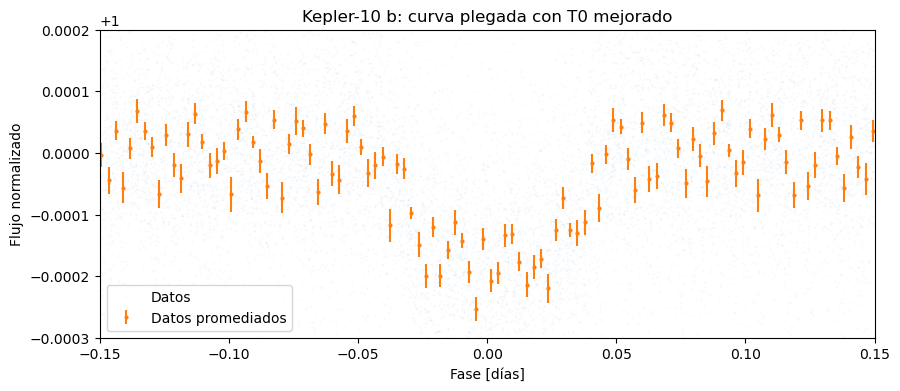

In [12]:
phase = fold_time(t, P_ref, T0_best_initial)
x_bin, y_bin, yerr_bin = bin_data_weighted(
    phase,
    flux,
    flux_err,
    nbins=300
)


plt.figure(figsize=(10, 4))
plt.plot(phase, flux, ".", alpha=0.04, markersize=1, label="Datos")
plt.errorbar(
    x_bin,
    y_bin,
    yerr=yerr_bin,
    fmt=".",
    markersize=4,
    label="Datos promediados"
)

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: curva plegada con T0 mejorado")
plt.xlim(-0.15, 0.15)
plt.ylim(0.9997, 1.0002)
plt.legend()
plt.show()

In [13]:
# Nos quedamos solo con una ventana alrededor del tránsito
mask_fit = (x_bin > -0.12) & (x_bin < 0.12)

x_fit = x_bin[mask_fit]
y_fit = y_bin[mask_fit]
yerr_fit = yerr_bin[mask_fit]

print("Número de puntos binned usados en el ajuste:", len(x_fit))

Número de puntos binned usados en el ajuste: 86


In [14]:
import batman
print("batman instalado correctamente")

batman instalado correctamente


In [15]:
P_fixed = 0.8374907
inc_fixed = 89.0  # grados

def batman_model_phase(x, Tc, rp, a_rs, F0):

    params = batman.TransitParams()

    params.t0 = Tc
    params.per = P_fixed
    params.rp = rp
    params.a = a_rs
    params.inc = inc_fixed
    params.ecc = 0.0
    params.w = 90.0

    params.u = [0.4, 0.2]
    params.limb_dark = "quadratic"

    m = batman.TransitModel(params, x)
    flux_model = m.light_curve(params)

    return F0 * flux_model

In [16]:
def log_prior_batman(theta):
    Tc, rp, a_rs, F0, sigma = theta

    if not (-0.1 < Tc < 0.1):
        return -np.inf

    if not (0.001 < rp < 0.1):
        return -np.inf

    if not (2.0 < a_rs < 20.0):
        return -np.inf

    if not (0.9 < F0 < 1.1):
        return -np.inf

    if not (1e-8 < sigma < 1e-1):
        return -np.inf

    return 0.0

In [17]:
def log_likelihood_batman(theta, x, y, yerr):
    Tc, rp, a_rs, F0, sigma = theta

    try:
        model = batman_model_phase(x, Tc, rp, a_rs, F0)
    except Exception:
        return -np.inf

    if not np.all(np.isfinite(model)):
        return -np.inf

    s2 = yerr**2 + sigma**2

    return -0.5 * np.sum((y - model)**2 / s2 + np.log(2 * np.pi * s2))

In [18]:
def log_probability_batman(theta, x, y, yerr):
    lp = log_prior_batman(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_batman(theta, x, y, yerr)

In [19]:
initial_batman = np.array([
    0.0,       # Tc
    0.0126,    # rp = Rp/Rs
    3.7,       # a/Rs
    1.0,       # F0
    3e-5       # sigma
])

ndim_batman = len(initial_batman)
nwalkers_batman = 40

rng = np.random.default_rng(789)

pos_batman = initial_batman + rng.normal(
    scale=[2e-3, 8e-4, 0.3, 2e-5, 5e-6],
    size=(nwalkers_batman, ndim_batman)
)

sampler_batman = emcee.EnsembleSampler(
    nwalkers_batman,
    ndim_batman,
    log_probability_batman,
    args=(x_fit, y_fit, yerr_fit)
)

sampler_batman.run_mcmc(pos_batman, 5000, progress=True)

100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:17<00:00, 290.30it/s]


State([[2.64366581e-03 1.19653328e-02 3.59553114e+00 9.99997325e-01
  3.28086399e-05]
 [7.43335141e-03 1.20819733e-02 3.56452078e+00 1.00000118e+00
  3.89448071e-05]
 [4.98460499e-03 1.24601781e-02 3.83124838e+00 1.00000509e+00
  3.72125372e-05]
 [5.99189863e-03 1.26020641e-02 3.73666798e+00 1.00000079e+00
  4.19128645e-05]
 [3.60844942e-03 1.21625096e-02 3.66842892e+00 1.00000554e+00
  3.57761013e-05]
 [4.41433660e-03 1.22861041e-02 3.80889587e+00 1.00000856e+00
  3.65721059e-05]
 [3.16038265e-03 1.22943683e-02 3.84527572e+00 1.00000043e+00
  3.60551342e-05]
 [4.86409455e-03 1.24224657e-02 3.89808334e+00 1.00000255e+00
  3.88263610e-05]
 [4.08758054e-03 1.17242412e-02 3.72796090e+00 9.99997799e-01
  3.89768705e-05]
 [4.45916274e-03 1.13492497e-02 3.59372318e+00 9.99997212e-01
  4.28117567e-05]
 [4.74843643e-03 1.21963795e-02 3.80247608e+00 9.99994504e-01
  4.20741426e-05]
 [4.98920030e-03 1.21875657e-02 3.76058454e+00 1.00000766e+00
  3.85287332e-05]
 [3.02197035e-03 1.28835630e-02 3.

Forma de la cadena: (5000, 40, 5)
Número de parámetros: 5
Número de etiquetas: 5


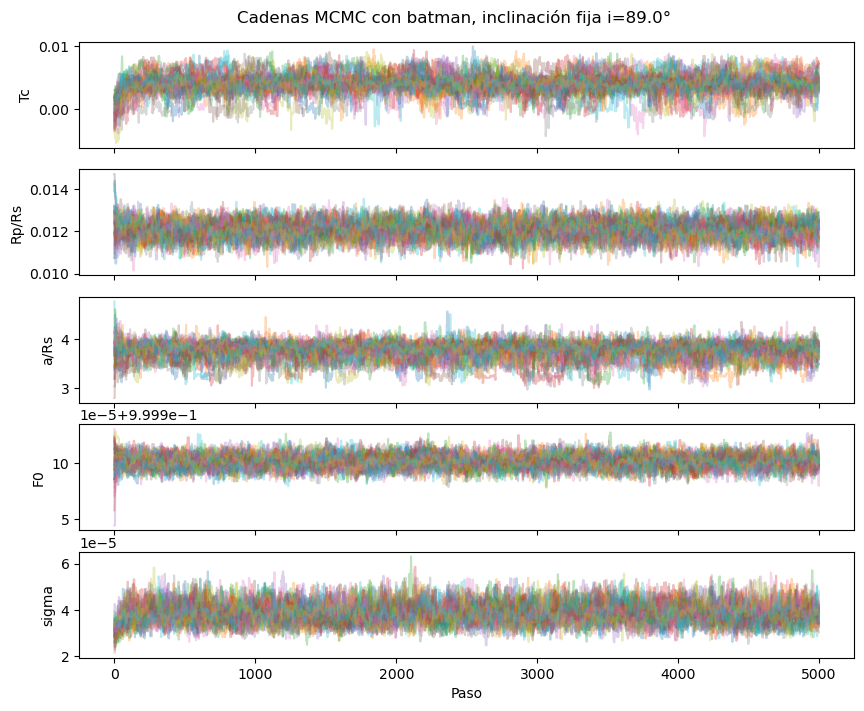

In [20]:
labels_batman = ["Tc", "Rp/Rs", "a/Rs", "F0", "sigma"]

samples_chain_batman = sampler_batman.get_chain()

ndim_batman = samples_chain_batman.shape[2]

print("Forma de la cadena:", samples_chain_batman.shape)
print("Número de parámetros:", ndim_batman)
print("Número de etiquetas:", len(labels_batman))

fig, axes = plt.subplots(
    ndim_batman,
    figsize=(10, 8),
    sharex=True
)

for i in range(ndim_batman):
    axes[i].plot(samples_chain_batman[:, :, i], alpha=0.3)
    axes[i].set_ylabel(labels_batman[i])

axes[-1].set_xlabel("Paso")

fig.suptitle(
    f"Cadenas MCMC con batman, inclinación fija i={inc_fixed}°",
    y=0.92
)

plt.savefig(
    "figures/kepler10b_cadenas_mcmc_batman.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

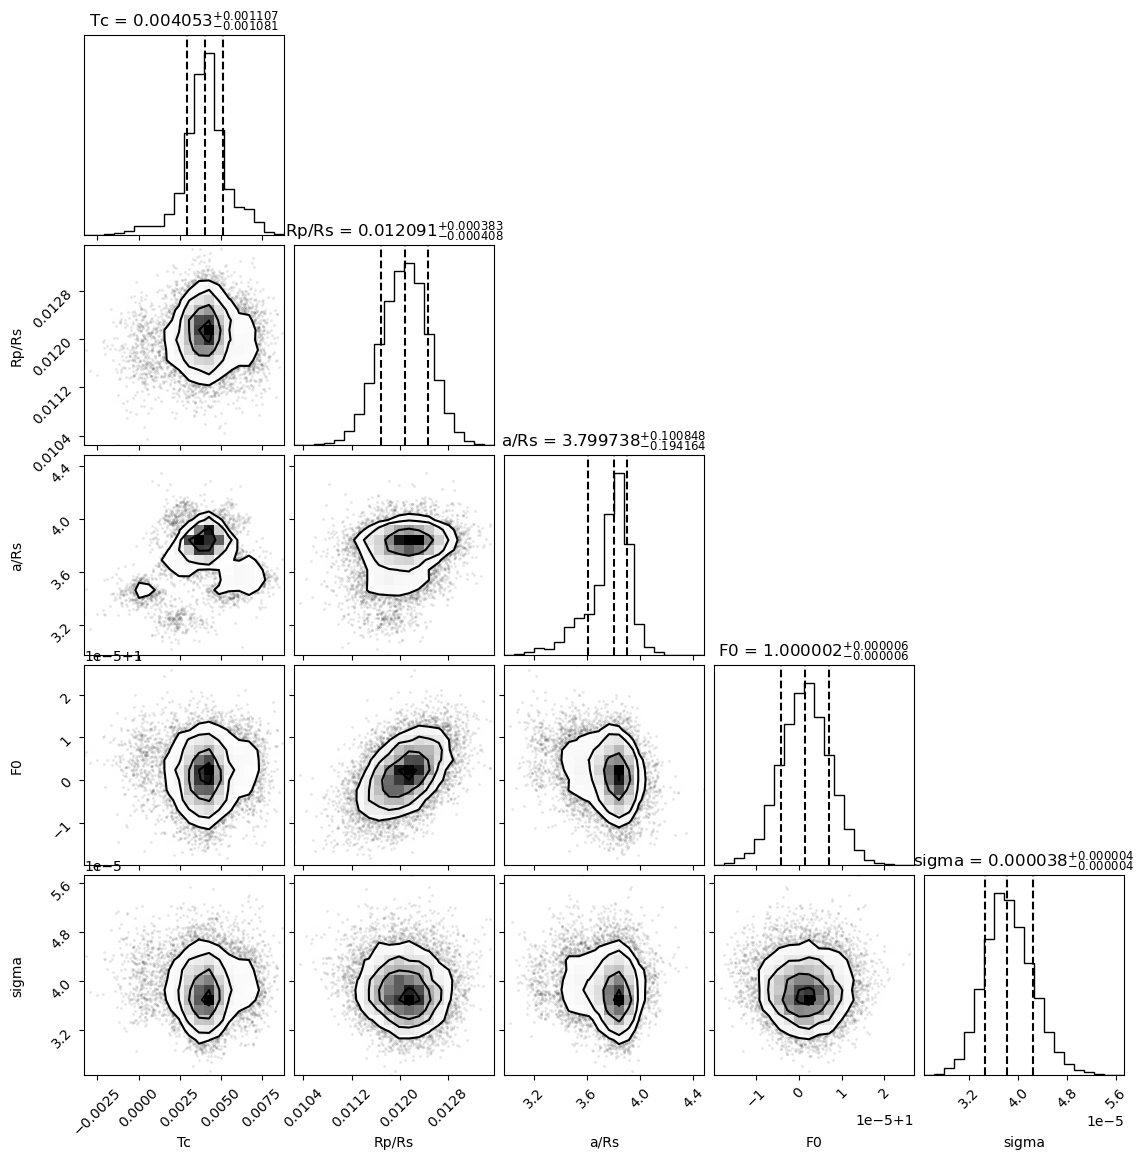

In [21]:
flat_samples_batman = sampler_batman.get_chain(
    discard=2000,
    thin=10,
    flat=True
)

fig = corner.corner(
    flat_samples_batman,
    labels=labels_batman,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".6f"
)

fig.savefig(
    "figures/kepler10b_corner_batman.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
for i, label in enumerate(labels_batman):
    q16, q50, q84 = np.percentile(
        flat_samples_batman[:, i],
        [16, 50, 84]
    )

    print(f"{label} = {q50:.8f} +{q84-q50:.8f} -{q50-q16:.8f}")

Tc = 0.00405279 +0.00110667 -0.00108073
Rp/Rs = 0.01209142 +0.00038325 -0.00040833
a/Rs = 3.79973770 +0.10084751 -0.19416410
F0 = 1.00000151 +0.00000559 -0.00000567
sigma = 0.00003825 +0.00000420 -0.00000354


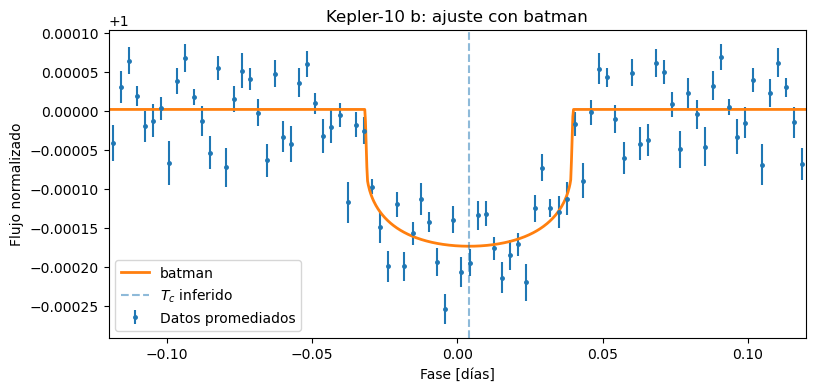

In [24]:
Tc_f, rp_f, a_rs_f, F0_f, sigma_f = np.median(
    flat_samples_batman,
    axis=0
)

x_model_batman = np.linspace(-0.12, 0.12, 1000)

y_model_batman = batman_model_phase(
    x_model_batman,
    Tc_f,
    rp_f,
    a_rs_f,
    F0_f
)

plt.figure(figsize=(9, 4))

plt.errorbar(
    x_fit,
    y_fit,
    yerr=yerr_fit,
    fmt=".",
    markersize=5,
    label="Datos promediados"
)

plt.plot(
    x_model_batman,
    y_model_batman,
    lw=2,
    label=fr"batman"
)

plt.axvline(Tc_f, linestyle="--", alpha=0.5, label=r"$T_c$ inferido")

plt.xlabel("Fase [días]")
plt.ylabel("Flujo normalizado")
plt.title("Kepler-10 b: ajuste con batman")
plt.xlim(-0.12, 0.12)
plt.legend()

plt.savefig(
    "figures/kepler10b_ajuste_batman.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
resultados_batman = np.array([
    Tc_f,
    rp_f,
    a_rs_f,
    F0_f,
    sigma_f
])

np.savetxt(
    "results/kepler10b_resultados_batman.txt",
    resultados_batman,
    header="Tc Rp_Rs a_Rs F0 sigma"
)

np.save(
    "results/kepler10b_flat_samples_batman.npy",
    flat_samples_batman
)

print("Resultados de batman guardados.")

Resultados de batman guardados.
